Algoritmos Genéticos y Optimización Heurística - UTN-FRT
# **Trabajo Práctico N°2**
##**Tema**: Simulated Annealing

Integrantes:

*   Mamani, Pablo
*   Monteros, Milagros Maria
*   Rocha, Felipe

El siguiente código es una implementación simple del algoritmo Simulated Annealing, donde la función “probabilidad“ se encarga de calcular la probabilidad de tomar una solución mala de todas formas. Se pide completar el código donde corresponda.

In [7]:
import random
import math

def SimulatedAnnealing(fitness, X_mejor, max_eps, bounds, cant_iterac, T0, mu):
    """Método de optimización Simulated Annealing
    PARAMETROS
    fitness : function
        Funcion de evaluacion a optimizar
    X_mejor: list
        Vector solucion inicial, desde donde parte la exploracion.
    max_eps: float
        Valor de distancia maxima del paso a recorrer en cada iteracion.
    bounds: list(tuple)
        Matriz de tamano nx2, donde n es la cantidad de variables que
        tiene el problema (cantidad de coordenadas del vector solución).
        En la primera columna se establecen los valores limites inferiores y
        en la segunda columna se establece los valores limite superiores.
        Observen que los valores de la primera columna siempre deben ser
        menores que los de la segunda).
    cant_iterac: integer
        Cantidad de iteraciones usada como condicion de terminacion.
    T0: float
        temperatura inicial (depende de los valores de fitness).
    mu: float
        factor que controla la forma de la función de enfriamiento.
    RETORNO
    X_mejor : list
        Vector solución correspondiente a la mejor solución encontrada.
    fX_mejor : list
        Valor de evaluación de la mejores solución encontrada.
    Trace_R : list
        Lista con los vectores dirección calculados en cada iteración.
    Trace_X : list
        Lista con las soluciones calculadas en cada iteración.
    Trace_X_mejor : list
        Lista con las mejores soluciones de cada iteración.
    Trace_f : list
        Lista con los valores de evaluación de la mejor y peor solución.
    """
    fX_mejor = 0
    Trace_R = []
    Trace_X = []
    Trace_X_mejor = []
    Trace_f = []
    #Validacion de parametros
    if len(X_mejor) == 0:
        print ('La solucion inicial debe tener al menos una variable.')
        return X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f
    if len(bounds) != len(X_mejor) or len(bounds[0]) != 2:
        print('La matriz de Bounds tiene un tamaño incorrecto.')
        return X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f
    if cant_iterac < 1:
        print('El número máximo de iteraciones debe ser positivo mayor a cero.')
        return X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f
    if T0 <= 0:
        print('La temperatura inicial debe ser positiva.')
        return X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f
    if max_eps <= 0:
        print('El tamaño del paso debe ser real y positivo.')
        return X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f

    # evaluacion inicial
    fX_mejor = fitness(X_mejor)
    fX_best = fX_mejor
    T = T0;

    # inicializar variables
    Trace_R.append([0 for xi in X_mejor]);
    Trace_X.append(X_mejor);
    Trace_X_mejor.append(X_mejor);
    Trace_f.append((fX_mejor,fX_mejor))
    it = 0
    cnt = 0
    sigue = True

    # repetir hasta que se cumpla la condicion de terminacion
    while sigue:

        # temperatura actual
        T = temperaturaSA(it, T0, mu)

        #  calculo el punto de exploracion
        X, R = puntoExploracion(X_mejor, max_eps)

        # verifico y corrijo que X este dentro del dominio
        for i in range(len(X)):
            X[i] = bounds[i][0] if X[i] < bounds[i][0] else X[i]
            X[i] = bounds[i][1] if X[i] > bounds[i][1] else X[i]

        # evaluo solucion
        fX0 = fX_mejor
        fX = fitness(X)

        #si la solucion actual es mejor que la que ya tenía
        if fX >= fX_mejor:
            X_mejor = X
            fX_mejor = fX
            cnt = 0
        else:
            cnt = cnt + 1

            #tiro una moneda para saber si acepto la solucion de todas formas
            p = probabilidadSA(fX, fX_mejor, T)

            if random.random() < p:
                ########################################### COMPLETAR AQUÍ ###########################################
                X_mejor = X
                fX_mejor = fX
                cnt = 0

        # guardo valores para analisis posterior
        Trace_R.append(R)
        Trace_X.append(X)
        Trace_X_mejor.append(X_mejor)
        Trace_f.append((max(fX, fX0), min(fX, fX0)))

        # condicion de terminacion
        if cnt > cant_iterac:
            sigue = False

        # incremento el tiempo
        it = it + 1

        # imprimir solo si obtuve una mejor solucion
        if fX >= fX0:
            print("It.{0}: {1} -> {2}".format(it,
                [round(xi,2) for xi in X], round(fX_mejor,4)))

    return X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f

def temperaturaSA(i, T0, mu):
    """Calcular la temperatura en la iteración "i" del algoritmo SA.
    PARAMETROS
    i: integer
        Numero de iteración actual del algoritmo.
    T0: float
        Temperatura inicial con la que inició el procedimiento.
    mu: float
        Coeficiente de enfriamiento.
    RETORNO
    T: float
        Valor de temepratura
    """
    ##################################################### COMPLETAR CÓDIGO #####################################################
    T = T0 * (mu ** i)  # Enfriamiento exponencial
    return T

def probabilidadSA(fX, fX_mejor, T):
    """Calcular la probabilidad para tomar una solucion mala en Simulated Annealing.
    PARAMETROS
    fX: float
        Valor de fitness de la solución generada.
    fX_mejor: float
        Valor de fitness de la solución previa que es mejor que la generada.
        Es decir, se cumple que fX < fX_mejor
    T: float
        Valor de temperatura actual.
    """
    Prob= math.exp((fX-fX_mejor)/T)
    return Prob

def puntoExploracion(X0, max_eps):
    """Calcular un nuevo punto de exploración o solución, a partir de
    una solución previa.

    PARAMETROS
    X0: list
        Vector solucion inicial.
    max_eps: float
        Valor del tamaño máximo del paso.

    RETORNO
    X : list
        Vector solución generado.
    R : list
        Vector dirección.
    """
    ##################################################### COMPLETAR CÓDIGO #####################################################

    import random
    import math

    R = []
    for i in range(len(X0)):
        # Generar dirección aleatoria entre -1 y 1
        r_i = random.uniform(-1, 1)
        R.append(r_i)

    # Normalizar R para que sea unitario
    norm = math.sqrt(sum(r**2 for r in R))
    if norm > 0:
        R = [r/norm for r in R]

    # Generar magnitud aleatoria
    eps = random.uniform(0, max_eps)

    # Calcular nuevo punto
    X = [X0[i] + eps * R[i] for i in range(len(X0))]

    return X, R

In [8]:
import random
import math

def SimulatedAnnealing(fitness, X_mejor, max_eps, bounds, cant_iterac, T0, mu):
    """Método de optimización Simulated Annealing
    PARAMETROS
    fitness : function
        Funcion de evaluacion a optimizar
    X_mejor: list
        Vector solucion inicial, desde donde parte la exploracion.
    max_eps: float
        Valor de distancia maxima del paso a recorrer en cada iteracion.
    bounds: list(tuple)
        Matriz de tamano nx2, donde n es la cantidad de variables que
        tiene el problema (cantidad de coordenadas del vector solución).
        En la primera columna se establecen los valores limites inferiores y
        en la segunda columna se establece los valores limite superiores.
        Observen que los valores de la primera columna siempre deben ser
        menores que los de la segunda).
    cant_iterac: integer
        Cantidad de iteraciones usada como condicion de terminacion.
    T0: float
        temperatura inicial (depende de los valores de fitness).
    mu: float
        factor que controla la forma de la función de enfriamiento.
    RETORNO
    X_mejor : list
        Vector solución correspondiente a la mejor solución encontrada.
    fX_mejor : list
        Valor de evaluación de la mejores solución encontrada.
    Trace_R : list
        Lista con los vectores dirección calculados en cada iteración.
    Trace_X : list
        Lista con las soluciones calculadas en cada iteración.
    Trace_X_mejor : list
        Lista con las mejores soluciones de cada iteración.
    Trace_f : list
        Lista con los valores de evaluación de la mejor y peor solución.
    """
    fX_mejor = 0
    Trace_R = []
    Trace_X = []
    Trace_X_mejor = []
    Trace_f = []
    #Validacion de parametros
    if len(X_mejor) == 0:
        print ('La solucion inicial debe tener al menos una variable.')
        return X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f
    if len(bounds) != len(X_mejor) or len(bounds[0]) != 2:
        print('La matriz de Bounds tiene un tamaño incorrecto.')
        return X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f
    if cant_iterac < 1:
        print('El número máximo de iteraciones debe ser positivo mayor a cero.')
        return X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f
    if T0 <= 0:
        print('La temperatura inicial debe ser positiva.')
        return X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f
    if max_eps <= 0:
        print('El tamaño del paso debe ser real y positivo.')
        return X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f

    # evaluacion inicial
    fX_mejor = fitness(X_mejor)
    fX_best = fX_mejor
    T = T0;

    # inicializar variables
    Trace_R.append([0 for xi in X_mejor]);
    Trace_X.append(X_mejor);
    Trace_X_mejor.append(X_mejor);
    Trace_f.append((fX_mejor,fX_mejor))
    it = 0
    cnt = 0
    sigue = True

    # repetir hasta que se cumpla la condicion de terminacion
    while sigue:

        # temperatura actual
        T = temperaturaSA(it, T0, mu)

        #  calculo el punto de exploracion
        X, R = puntoExploracion(X_mejor, max_eps)

        # verifico y corrijo que X este dentro del dominio
        for i in range(len(X)):
            X[i] = bounds[i][0] if X[i] < bounds[i][0] else X[i]
            X[i] = bounds[i][1] if X[i] > bounds[i][1] else X[i]

        # evaluo solucion
        fX0 = fX_mejor
        fX = fitness(X)

        #si la solucion actual es mejor que la que ya tenía
        if fX >= fX_mejor:
            X_mejor = X
            fX_mejor = fX
            cnt = 0
        else:
            cnt = cnt + 1

            #tiro una moneda para saber si acepto la solucion de todas formas
            p = probabilidadSA(fX, fX_mejor, T)

            if random.random() < p:
                ########################################### COMPLETAR AQUÍ ###########################################
                X_mejor = X
                fX_mejor = fX
                cnt = 0

        # guardo valores para analisis posterior
        Trace_R.append(R)
        Trace_X.append(X)
        Trace_X_mejor.append(X_mejor)
        Trace_f.append((max(fX, fX0), min(fX, fX0)))

        # condicion de terminacion
        if cnt > cant_iterac:
            sigue = False

        # incremento el tiempo
        it = it + 1

        # imprimir solo si obtuve una mejor solucion
        if fX >= fX0:
            print("It.{0}: {1} -> {2}".format(it,
                [round(xi,2) for xi in X], round(fX_mejor,4)))

    return X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f

def temperaturaSA(i, T0, mu):
    """Calcular la temperatura en la iteración "i" del algoritmo SA.
    PARAMETROS
    i: integer
        Numero de iteración actual del algoritmo.
    T0: float
        Temperatura inicial con la que inició el procedimiento.
    mu: float
        Coeficiente de enfriamiento.
    RETORNO
    T: float
        Valor de temepratura
    """
    ##################################################### COMPLETAR CÓDIGO #####################################################
    T = T0 * math.exp(-mu * i)  # Enfriamiento exponencial
    return T

def probabilidadSA(fX, fX_mejor, T):
    """Calcular la probabilidad para tomar una solucion mala en Simulated Annealing.
    PARAMETROS
    fX: float
        Valor de fitness de la solución generada.
    fX_mejor: float
        Valor de fitness de la solución previa que es mejor que la generada.
        Es decir, se cumple que fX < fX_mejor
    T: float
        Valor de temperatura actual.
    """
    Prob = math.exp((fX - fX_mejor)/T)
    return Prob

def puntoExploracion(X0, max_eps):
    """Calcular un nuevo punto de exploración o solución, a partir de
    una solución previa.

    PARAMETROS
    X0: list
        Vector solucion inicial.
    max_eps: float
        Valor del tamaño máximo del paso.

    RETORNO
    X : list
        Vector solución generado.
    R : list
        Vector dirección.
    """
    ##################################################### COMPLETAR CÓDIGO #####################################################

    R = []
    for i in range(len(X0)):
        # Generar dirección aleatoria entre -1 y 1
        r_i = random.uniform(-1, 1)
        R.append(r_i)

    # Normalizar R para que sea unitario
    norm = math.sqrt(sum(r**2 for r in R))
    if norm > 0:
        R = [r/norm for r in R]

    # Generar magnitud aleatoria
    eps = random.uniform(0, max_eps)

    # Calcular nuevo punto
    X = [X0[i] + eps * R[i] for i in range(len(X0))]

    return X, R

## Ejercicio 2
Compruebe el funcionamiento del algoritmo, buscando un óptimo local en los siguientes casos:

1. F(x, y) = -x^2 - y^2, x,y ∈ [-5, 5]
2. g(x)= -0.01 x^2-cos(2x), x ∈ [-4𝜋, 4𝜋]
3. G(x, y) = -0.01 (x^2+y^2)-cos(2x)-cos(2y), x,y ∈ [-4𝜋, 4𝜋]

En cada caso se pide:
* Ajuste adecuadamente todos los parámetros del algoritmo, de manera de asegurar que encuentre el óptimo **global** (o un óptimo local cercano al global) independientemente de cuál sea el punto inicial, en más del 80% de las ejecuciones. Considere dos cifras decimales de precisión para determinar que llegó al óptimo.
* Genere un gráfico con la “caminata” realizada, es decir donde se muestre todos los puntos por donde el algoritmo fue explorando, desde el punto inicial hasta llegar a la solución final.
* Generar un gráfico con los valor de fitness de las soluciones encontradas en cada iteración del algoritmo.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from mpl_toolkits.mplot3d import Axes3D

def graficarEvolucionFitness(trace_f):
    """Método para graficar la evolucion del fitness con las iteraciones.
    PARAMETROS
    trace_f : list
        Lista con los valores de evaluación de la mejor y peor solución.
    """
    fig = plt.figure()
    ax = plt.axes()
    x = np.linspace(0, 10, 1000)
    x = [i for i in range(len(trace_f))];
    best = [t[0] for t in trace_f];
    worst = [t[1] for t in trace_f];
    plt.plot(x, best, label='Mejor solución');
    plt.plot(x, worst, label='Peor solución');

    # Add title and axis names
    plt.title('Valores de Evaluación')
    plt.xlabel('Iteración')
    plt.ylabel('Fitness')
    plt.grid()
    plt.legend()

def graficarTemperatura(T0, mu, cant_iterac):
    """Graficar funcion de enfriamiento."
    PARAMETROS
    T0: float
        Temperatura inicial
    mu: float
        Coeficiente de enfriamiento
    cant_itera: int
        Cantidad total de iteraciones.
    """
    fig = plt.figure()
    ax = fig.gca()
    X = []; Y = []
    for i in range(cant_iterac):
        T = temperaturaSA(i, T0, mu)
        X.append(i)
        Y.append(T)

    # Plot the line.
    plt.plot(X, Y, antialiased=False)

    # Add title and axis names
    plt.title('Función de Temperatura Evaluación')
    plt.xlabel('T')
    plt.ylabel('T(t)')
    plt.grid()


def graficarCaminata(fitness, solutions,  bounds, resolution, alpha=0.5):
    """Graficar la funcion de evaluacion y las soluciones encontradas.
    PARAMETROS
    fitness : function
        Función de evaluación a optimizar
    solutions : list
        Lista de soluciones encontradas con método de optimización.
    bounds: list(tuple)
        Matriz de tamano nx2, donde n es la cantidad de variables que
        tiene el problema (cantidad de coordenadas del vector solución).
    resolution : float
        Resolución para graficar la función. Tomar un valor Mayor a 0.1.
    alpha : float
        Transparencia para el grafico de la función.
    """
    if len(bounds) == 1:
        fig = plt.figure()
        ax = fig.gca()
        ranges = []
        for i in range(len(bounds)):
            steps = round((bounds[i][1] - bounds[i][0]) / resolution)
            ranges.append([bounds[i][0] + s*resolution for s in range(steps)])
        X = []; Y = []
        for i, xi in enumerate(ranges[0]):
            X.append(xi)
            Y.append(fitness([xi]))

        # Plot the line.
        plt.plot(X, Y, antialiased=False, alpha=alpha)

        # Add title and axis names
        plt.title('Función de Evaluación')
        plt.xlabel('x')
        plt.ylabel('f(x)')
        plt.grid()
        x = [s[0] for s in solutions]
        y = [fitness(s) for s in solutions]
        ax.scatter(x, y, c='k', marker='o')
    elif len(bounds) == 2:
        fig = plt.figure()
        ax = fig.add_subplot(projection='3d')
        ranges = []
        for i in range(len(bounds)):
            steps = round((bounds[i][1] - bounds[i][0]) / resolution)
            ranges.append([bounds[i][0] + s*resolution for s in range(steps)])
        X = []; Y = []; Z = []
        for i, xi in enumerate(ranges[0]):
            x_row = []; y_row = []; z_row = []
            for j, yj in enumerate(ranges[1]):
                x_row.append(xi)
                y_row.append(yj)
                z_row.append(fitness([xi, yj]))
            X.append(x_row)
            Y.append(y_row)
            Z.append(z_row)

        # Plot the surface.
        surf = ax.plot_surface(X, Y, np.array(Z), cmap=cm.coolwarm, linewidth=0,
            antialiased=False, alpha=alpha)

        # Add title and axis names
        plt.title('Función de Evaluación')
        plt.xlabel('x')
        plt.ylabel('y')
        ax.set_zlabel('f(x,y)')

        # Add a color bar which maps values to colors.
        fig.colorbar(surf, shrink=0.5, aspect=5)
        x = [s[0] for s in solutions]
        y = [s[1] for s in solutions]
        z = [fitness(s)+1 for s in solutions]
        ax.scatter(x, y, z, c='k', marker='o')
        ax.view_init(elev=40., azim=60)
    else:
        print("No implementado para más de dos variables.")

**PRIMERA FUNCIÓN**



*   F(x, y) = -x^2 - y^2, x,y ∈ [-5, 5]



It.1: [4.59, 4.72] -> -43.3662
It.3: [4.39, 4.91] -> -43.3941
It.4: [4.34, 4.9] -> -42.8826
It.5: [4.27, 4.91] -> -42.3751
It.6: [4.28, 4.82] -> -41.5835
It.7: [4.07, 4.83] -> -39.944
It.8: [3.83, 4.54] -> -35.2296
It.9: [3.58, 4.29] -> -31.1869
It.17: [3.6, 3.89] -> -28.1209
It.18: [3.21, 4.1] -> -27.1681
It.21: [2.93, 4.02] -> -24.7778
It.24: [2.59, 3.79] -> -21.073
It.28: [2.44, 3.64] -> -19.2165
It.29: [2.22, 3.33] -> -15.9746
It.30: [2.39, 3.18] -> -15.7896
It.31: [2.13, 3.21] -> -14.8788
It.32: [2.02, 3.11] -> -13.7677
It.33: [1.96, 3.13] -> -13.6168
It.38: [2.02, 2.7] -> -11.3852
It.39: [2.01, 2.66] -> -11.0881
It.41: [2.06, 2.61] -> -11.0476
It.43: [2.0, 2.57] -> -10.5886
It.44: [1.95, 2.41] -> -9.598
It.45: [1.94, 2.4] -> -9.5303
It.46: [2.17, 2.15] -> -9.3238
It.49: [2.15, 2.01] -> -8.6701
It.52: [2.12, 1.66] -> -7.2306
It.53: [2.0, 1.75] -> -7.0416
It.54: [1.87, 1.72] -> -6.438
It.55: [1.52, 1.89] -> -5.9098
It.56: [1.39, 1.89] -> -5.5285
It.60: [1.01, 1.89] -> -4.5742
It.62

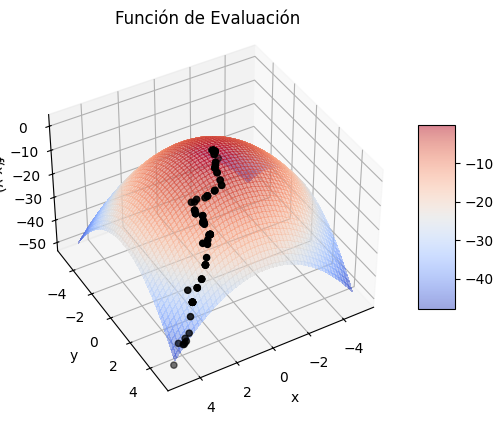

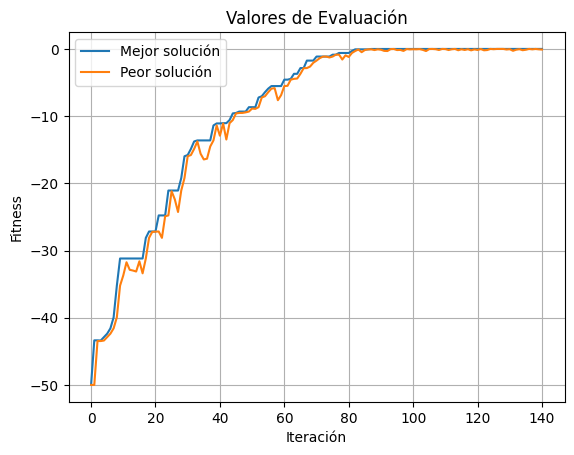

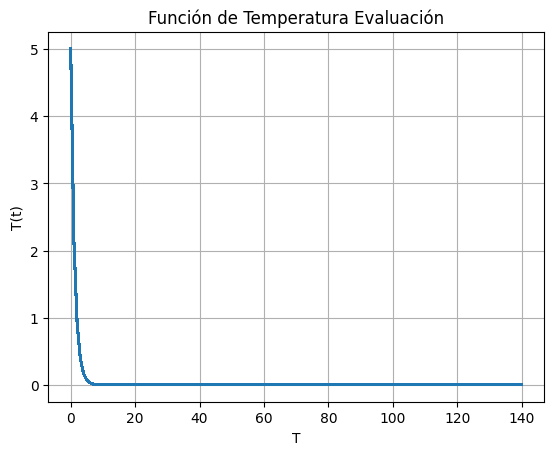

In [10]:
import math

def f(X_vars):
    return -sum( [xi**2 for xi in X_vars] )

bounds_F = [(-5,5), (-5,5)]

# punto inicial en una de las esquinas
x0 = [row[1] for row in bounds_F]

max_eps = 0.5
cant_iterac = 30
T0 = 5.0
mu = 0.85


X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f = SimulatedAnnealing(
    f, x0, max_eps, bounds_F, cant_iterac, T0, mu)

print("-----")
print("Solución: {0}".format(X_mejor))
print("Fitness: {0}".format(fX_mejor))
print("Iteraciones: {0}".format(len(Trace_X)-1))

graficarCaminata(f, Trace_X_mejor, bounds_F, 0.1)
graficarEvolucionFitness(Trace_f)
graficarTemperatura(T0, mu, len(Trace_f))

**SEGUNDA FUNCIÓN**

*   g(x)= -0.01 x^2-cos(2x), x ∈ [-4𝜋, 4𝜋]

It.1: [12.49] -> -2.5484
It.3: [12.51] -> -2.5603
It.5: [12.49] -> -2.5459
It.7: [12.48] -> -2.5441
It.9: [12.57] -> -2.5791
It.10: [12.53] -> -2.5663
It.11: [12.52] -> -2.5649
It.12: [12.42] -> -2.4968
It.14: [12.36] -> -2.4481
It.15: [12.28] -> -2.352
It.16: [12.23] -> -2.2759
It.19: [12.33] -> -2.4086
It.22: [12.13] -> -2.1177
It.23: [11.98] -> -1.828
It.25: [11.97] -> -1.7988
It.29: [11.93] -> -1.7245
It.30: [11.74] -> -1.2989
It.32: [11.66] -> -1.1269
It.35: [11.49] -> -0.762
It.36: [11.34] -> -0.508
It.37: [11.2] -> -0.3372
It.38: [11.16] -> -0.3027
It.39: [11.14] -> -0.2844
It.40: [10.96] -> -0.2034
It.42: [10.94] -> -0.203
It.49: [10.93] -> -0.2031
It.61: [10.94] -> -0.203
-----
Solución: [10.942333359427026]
Fitness: -0.2030104317456234
Iteraciones: 82


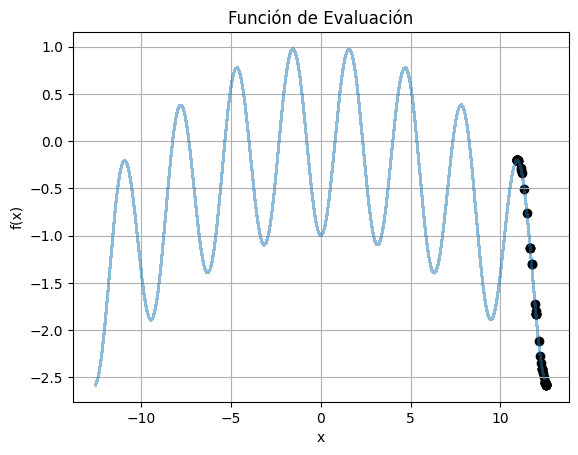

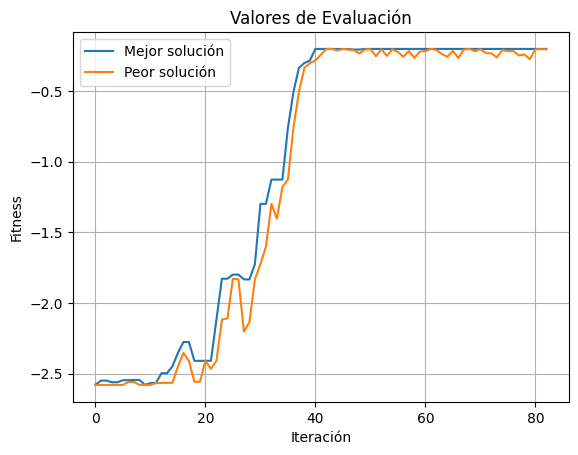

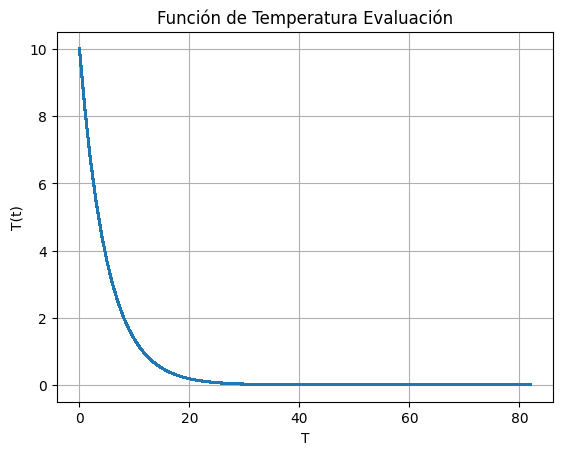

In [11]:
import math

def g(X_vars):
    return -0.01 * sum([xi**2 for xi in X_vars]) - sum([math.cos(2*xi) for xi in X_vars])

bounds_g = [(-4*math.pi, 4*math.pi)]

# punto inicial en una de las esquinas
x0 = [row[1] for row in bounds_g]

### COMPLETAR CÓDIGO ####
#tamaño máximo del paso
max_eps = 0.2
#cantidad de iteraciones para la condicion de temrinación
cant_iterac = 20
#temperatura inicial (depende de los valores de fitness en el problema)
T0 = 10
#coeficiente de enfriamiento (controla que tan rápido se 'enfria' el algoritmo)
mu = 0.2
###

X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f = SimulatedAnnealing(
    g, x0, max_eps, bounds_g, cant_iterac, T0, mu)

print("-----")
print("Solución: {0}".format(X_mejor))
print("Fitness: {0}".format(fX_mejor))
print("Iteraciones: {0}".format(len(Trace_X)-1))

graficarCaminata(g, Trace_X_mejor, bounds_g, 0.1)
graficarEvolucionFitness(Trace_f)
graficarTemperatura(T0, mu, len(Trace_f))

**TERCERA FUNCIÓN**

*   3. G(x, y) = -0.01 (x^2+y^2)-cos(2x)-cos(2y), x,y ∈ [-4𝜋, 4𝜋]

It.1: [12.42, 12.37] -> -4.958
It.3: [12.14, 12.36] -> -4.5722
It.4: [12.14, 12.21] -> -4.3817
It.5: [12.57, 11.63] -> -3.6241
It.7: [10.79, 11.33] -> -0.7457
It.18: [11.13, 11.22] -> -0.6305
It.30: [7.95, 10.89] -> 0.1434
It.44: [7.8, 10.91] -> 0.1809
-----
Solución: [7.803380972518346, 10.908724623214367]
Fitness: 0.18090540342423633
Iteraciones: 65


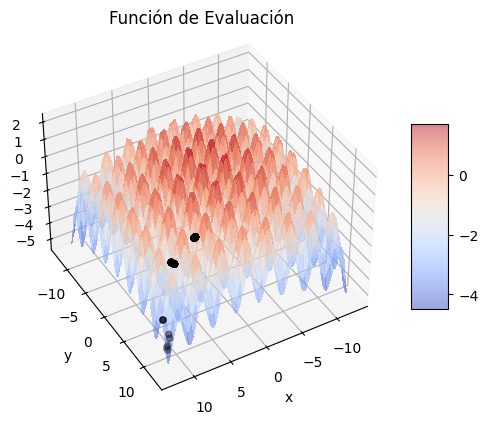

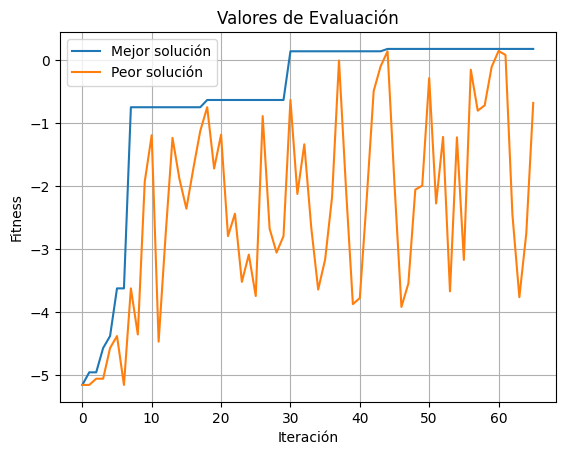

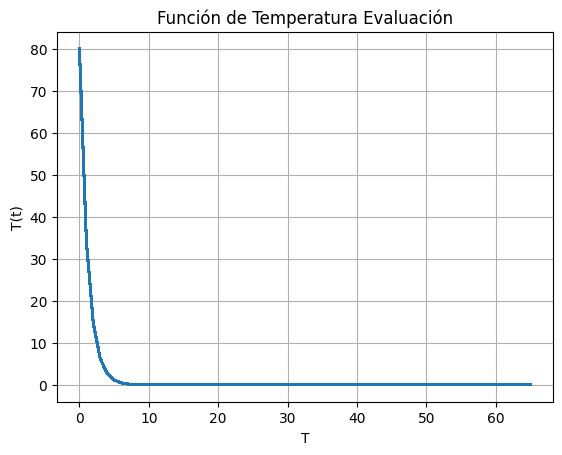

In [12]:
import math

def g(X_vars):
    return -0.01 * sum([xi**2 for xi in X_vars]) - sum([math.cos(2*xi) for xi in X_vars])

bounds_G = [(-4*math.pi, 4*math.pi) for i in range (2)]

# punto inicial en una de las esquinas
x0 = [row[1] for row in bounds_G]

### COMPLETAR CÓDIGO ####
#tamaño máximo del paso
max_eps = 3.3
#cantidad de iteraciones para la condicion de temrinación
cant_iterac = 20
#temperatura inicial (depende de los valores de fitness en el problema)
T0 = 80
#coeficiente de enfriamiento (controla que tan rápido se 'enfria' el algoritmo)
mu = 0.85
###

X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f = SimulatedAnnealing(
    g, x0, max_eps, bounds_G, cant_iterac, T0, mu)

print("-----")
print("Solución: {0}".format(X_mejor))
print("Fitness: {0}".format(fX_mejor))
print("Iteraciones: {0}".format(len(Trace_X)-1))

graficarCaminata(g, Trace_X_mejor, bounds_G, 0.1)
graficarEvolucionFitness(Trace_f)
graficarTemperatura(T0, mu, len(Trace_f))

## Ejercicio 3
Contestar las siguientes preguntas:
1.    Explique brevemente con sus palabras cómo es el mecanismo que usa Simulated Annealing para "escapar" de los óptimos locales.

2.    ¿Qué criterio utilizó para determinar el valor de la temperatura inicial (T0) y el coeficiente de enfriamiento (mu) a la hora de ajustar el algoritmo en cada problema dado?

**CONCLUSIONES**



1.   Este algoritmo puede aceptar peores soluciones para poder explorar mejor todo el espacio de la función para obtener el valor
optimo global y no estancarse en el primer valor optimo local, como es en el caso de Hill climbing. Para realizar esto, si encontramos una solución un poco peor, la aceptemos igual con cierta probabilidad, como si lanzáramos una moneda y a medida que avanza el proceso, cada vez es menos probable aceptar soluciones peores porque la "temperatura" baja a medida que va aumentando el numero de iteraciones provocando que el algoritmo no pueda aceptar peores soluciones.

2.   Los criterios que usamos son:

     Para la primera funcion:

Para este problema, se eligió una temperatura inicial
T0=5.0 porque permite que, en las primeras etapas del algoritmo, se acepten soluciones peores con una probabilidad razonable. Esto es fundamental para que el algoritmo explore el espacio de búsqueda y no se quede atrapado rápidamente en óptimos locales. Por otro lado, el coeficiente de enfriamiento
mu=0.85 se seleccionó para que la temperatura disminuya de forma gradual a lo largo de las iteraciones. De esta manera, el algoritmo comienza siendo permisivo y, a medida que avanza, se vuelve más estricto, favoreciendo la convergencia hacia una solución óptima.

     Para la segunda funcion
  

*   Elegimos una temperatura alta de T0=80
*   Ademas un mu bajo de 0.66

     Para la tercera funcion

*   Elegimos una temperatura alta de T0=90
*   Ademas un mu bajo de 0.375








